# Validation: Python `classify_events` vs. Lung-Hao's MATLAB Pipeline

**Objective:** cross-check the Python event classification pipeline (`classify_events` in `fp_functions/helper_functions.py`) against an independent MATLAB implementation written by a labmate, Lung-Hao (see `matlab_pipeline/`), as a sanity check that trial outcomes are labeled consistently by both.

**Note:** this compares against code I did not write; see the Author section of the main README for attribution. This notebook is my own validation analysis, run on both pipelines' outputs.


## Setup (shared across the RRM003/RRM004 notebooks)

This repeats the imports and data-loading cells common to every RRM003/RRM004 notebook, so each one runs standalone rather than depending on cells left over in a different notebook. **Update the file paths below** to point at your own copy of the data (either the lab server path shown, or the `Data/` folder bundled in this repo).


In [1]:
#import packages

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import re
import matplotlib as mpl
from matplotlib import rc
from scipy import signal
from IPython.core.debugger import set_trace

#import behaviour functions
from main import *
from behaviour_functions.helper_functions import *
from behaviour_functions.plotting_functions import *

# import FP functions
from fp_functions.helper_functions import *
from fp_functions.plotting_fp import *
from fp_functions.utils_albert import *

CaImAn not installed or environment not activated, certain functions might not be usable


In [2]:
# load sessions for each mouse

# data paths - NOTE: change this to correct path based on computer using
fp_folder_RRMM003 = '/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM003'
behavior_folder_RRMM003 = '/Volumes/Wilbrecht_file_server/LauraG/RR_Behavior_Data/RRM003'

fp_folder_RRMM004 = '/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM004'
behavior_folder_RRMM004 = '/Volumes/Wilbrecht_file_server/LauraG/RR_Behavior_Data/RRM004'

# load behaviour data
bdata_RM0003 = load_behavior_FP(behavior_folder_RRMM003)
bdata_RM0004 = load_behavior_FP(behavior_folder_RRMM004)


In [9]:
## Get Data RR
animal = 'RRM004'
day = 158
fp_folder = fp_folder_RRMM004
behavior_folder = behavior_folder_RRMM004

behaviour_summary, data_rr, data_fp = get_data_rr(fp_folder, behavior_folder, animal, day)

/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM004/FP_Dayp158_epoch-5_ID-RRM004_2021-04-26T14_59_40.csv
Pellets Revealed R1: 25
Pellets Eaten R1: 25
Number of 0% Offer Tone Rejections: 8
Pellets Revealed R2: 23
Pellets Eaten R2: 22
Number of 0% Offer Tone Rejections: 15
Pellets Revealed R3: 15
Pellets Eaten R3: 15
Number of 0% Offer Tone Rejections: 27
Pellets Revealed R4: 19
Pellets Eaten R4: 17
Number of 0% Offer Tone Rejections: 27
Percentage of No Offer Rejections: 0.4426229508196721


In [ ]:
# Alignment used throughout this comparison (matches the offer-tone alignment used in notebook 2)
alignment = 'offer_tone'


## Comparing Lung-Hao's Classify Event Function from MatLab vs `Classify_Events`



In [15]:
# Load Data
path_matlab = '/Volumes/Wilbrecht_file_server/LauraG/RR_Analysis_MatLab/'
behaviour_csv = 'RR_FP_Dayp158_epoch-5_ID-RRM004_behaviour_summary.csv'
RRM004_summary = pd.read_csv(path_matlab+behaviour_csv,
                             names=['offer_tone_ts','restaurant', 'offer_tone', 'outcome', 'reject_ts'])


In [16]:
# Grab FP Traces 

condition = 'reject'
channel = 'green'
side = 'left'
trigger_mode = 'TRIG1'
split = 'none'
baseline_method = 'robust_fast'

signals_left, t_left = grab_fp_traces_matlabcsv(channel, 'left', condition, data_fp, RRM004_summary, trigger_mode, baseline_method, split)
signals_right, t_right = grab_fp_traces_matlabcsv(channel, 'right', condition, data_fp, RRM004_summary, trigger_mode, baseline_method, split)

(-0.5, 0.5)

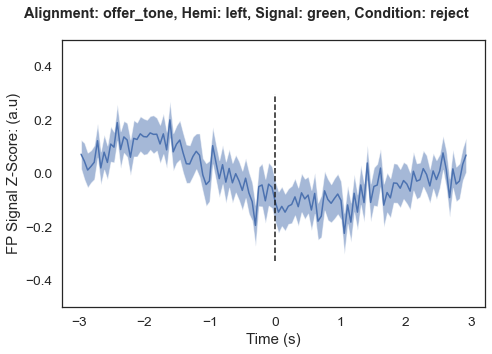

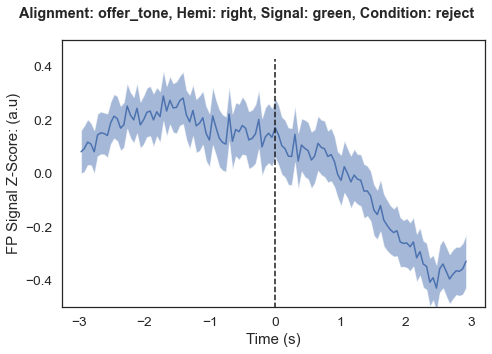

In [17]:
# Plot FP Traces

plot_opt = 'none'
y_min=-0.5
y_max=0.5

plot_trial_avg_FP_aligned(signals_left, t_left, plot_opt, alignment, 'left', channel, condition, baseline_method)
plt.ylim(y_min,y_max)
plot_trial_avg_FP_aligned(signals_right, t_right, plot_opt, alignment, 'right', channel, condition, baseline_method)
plt.ylim(y_min,y_max)